In [2]:
import torch
import torch.nn as nn   
import torch.optim as optim

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

The maximum value in X is: 16.0


(1797, 8, 8)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


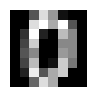

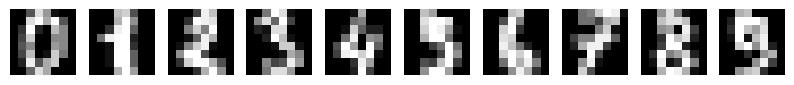

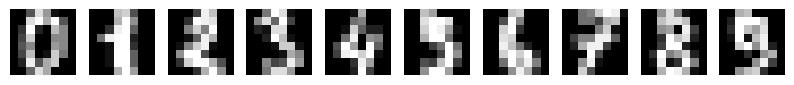

In [36]:
datensatz = load_digits()
X = datensatz.data
y = datensatz.target

# find the maximum value in X:
max_value = X.max()
# use f-syntax to print the maximum value:
print(f"The maximum value in X is: {max_value}") # use f-syntax to print
# print newline character:
print("\n")  # print newline character

X = X/16.0 # normalize the data

print(datensatz.images.shape)
# show a single image of digits:
import matplotlib.pyplot as plt
# display the image smaller:
plt.figure(figsize=(1, 1)) 
#remove axis labels:
plt.axis('off')  # Turn off axis
plt.imshow(datensatz.images[0], cmap='gray')
print(datensatz.images[0])
plt.show()

# show the first 10 images of digits:
plt.figure(figsize=(10, 1)) 
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(datensatz.images[i], cmap='gray')
    plt.axis('off')

# show the first 10 images of digits:
plt.figure(figsize=(10, 1)) 
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X[i].reshape(8, 8), cmap='gray')
    plt.axis('off') 


(1797, 64)
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


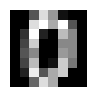

In [28]:
print(X.shape)
#print the values of the first sample in a single row:
plt.figure(figsize=(1, 1))
plt.imshow(X[0].reshape(8, 8), cmap='gray')
plt.axis('off')  # Turn off
print(X[0])

In [32]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# In Torch-Tensoren umwandeln
X_train = torch.tensor(X_train, dtype=torch.float32).view(-1, 1, 8, 8)
X_test = torch.tensor(X_test, dtype=torch.float32).view(-1, 1, 8, 8)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
print(X_train.device)

# Einfaches neuronales Netz definieren
model1 = nn.Sequential(
     nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1), # Stride ist die Schrittweite, 
     # Padding ist die Anzahl der Pixel um die Eingabe zu umgeben, damit die Ausgabe nicht kleiner wird
     nn.ReLU(),
     nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # 2x2 Pooling mit Stride=2 und Padding=0 -> 4x4 Ausgabe
     nn.Flatten(),
     nn.Linear(8*4*4, 10) # 8 Filter mit 4x4 Ausgabe
)

# Verlustfunktion und Optimierer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.parameters(), lr=0.01) # Alternativen: SGD oder Adam

# Training
epochs = 100

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model1(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch) % 20 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}")

# Testen
with torch.no_grad():
        y_pred = model1(X_test)
        predicted = torch.argmax(y_pred, dim=1)
        #print(predicted)
        accuracy = accuracy_score(y_test, predicted)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(confusion_matrix(y_test, predicted))



cpu
Epoch [0/100], Loss: 2.4010
Epoch [20/100], Loss: 0.7655
Epoch [40/100], Loss: 0.2409
Epoch [60/100], Loss: 0.1369
Epoch [80/100], Loss: 0.0936
Test Accuracy: 96.94%
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 26  1  0  0  0  0  0  0  1]
 [ 0  1 32  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  2  0  0  0  1  0  0 27  0]
 [ 0  0  0  0  0  0  0  0  0 40]]


In [33]:
torch.save(model1, 'digits_modell.pth')

In [34]:
import torch
from torch import nn

# Laden des gesparten Models
modell_geladen = torch.load('digits_modell.pth',weights_only=False)
modell_geladen.eval()  # In den Evaluierungsmodus schalten

outputs = modell_geladen(X_test)

_, vorhersage = torch.max(outputs, dim=1)
# Beispiel für Genauigkeit
korrekt = (vorhersage == y_test).sum().item()
genauigkeit = korrekt / len(y_test)
print(f'Genauigkeit: {genauigkeit:.4f}')

Genauigkeit: 0.9694
